#### Preprocessing

In [2]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tslearn.metrics import cdist_dtw
from tslearn.clustering import TimeSeriesKMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_path = '/Users/rheajaisinghani/Desktop/Applied DS/Dexcom Data/'

csv_files = glob.glob(data_path + '*.csv')

df_list = []

for file in csv_files:
    df = pd.read_csv(file, skiprows=range(1, 11))
    df_list.append(df)

dexcom_df = pd.concat(df_list, ignore_index=True)

dexcom_df.shape

(314846, 14)

In [4]:
timeseries_data = dexcom_df[['Glucose Value (mg/dL)']]

In [5]:
dexcom_df.loc[dexcom_df['Glucose Value (mg/dL)'] == 'Low', 'Glucose Value (mg/dL)'] = 39
dexcom_df.loc[dexcom_df['Glucose Value (mg/dL)'] == 'High', 'Glucose Value (mg/dL)'] = 401

In [6]:
dexcom_df['Glucose Value (mg/dL)'] = dexcom_df['Glucose Value (mg/dL)'].astype(int)

In [7]:
dexcom_df['Timestamp'] = pd.to_datetime(dexcom_df['Timestamp (YYYY-MM-DDThh:mm:ss)'])

Text(0, 0.5, 'Number of Days')

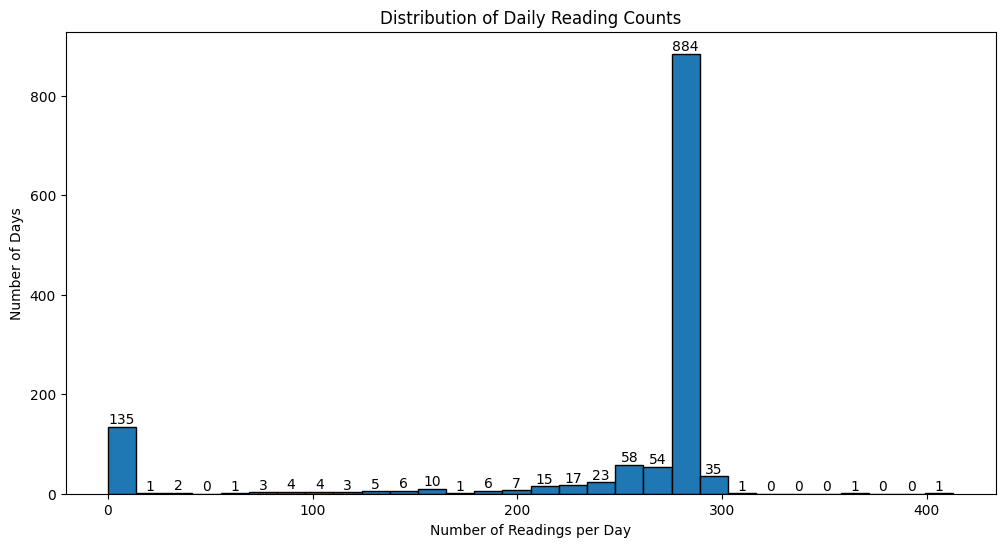

In [33]:
daily_counts = pd.DataFrame(dexcom_df.groupby(pd.Grouper(key='Timestamp', freq='D')).size())
plt.figure(figsize=(12, 6))
n, bins, patches = plt.hist(daily_counts[0], bins=30, edgecolor='black')

# Add count labels on top of each bar
for i in range(len(patches)):
    plt.text(patches[i].get_x() + patches[i].get_width()/2., 
             patches[i].get_height(),
             int(n[i]),
             ha='center', va='bottom')
plt.title('Distribution of Daily Reading Counts')
plt.xlabel('Number of Readings per Day')
plt.ylabel('Number of Days')

In [8]:
# Data was weird for these dates. Multiple records for same time points.
dates_to_remove = ['2023-11-21', '2024-02-14', '2024-08-07']
dates_to_remove = [pd.to_datetime(date).date() for date in dates_to_remove]
dexcom_df = dexcom_df[~dexcom_df['Timestamp'].dt.date.isin(dates_to_remove)]

#### EDA

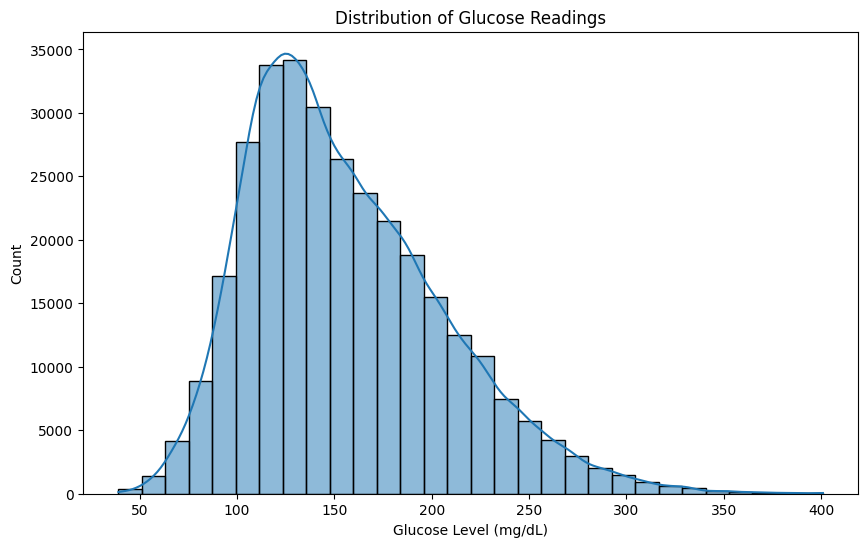

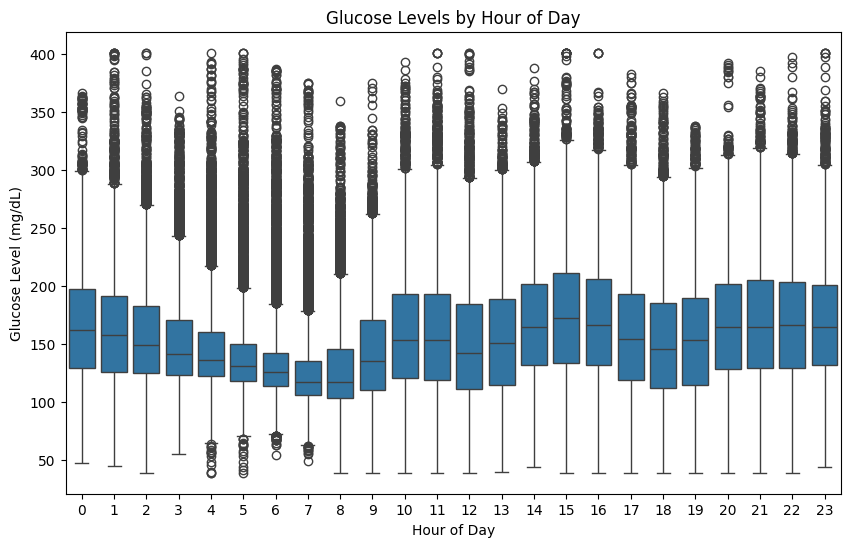

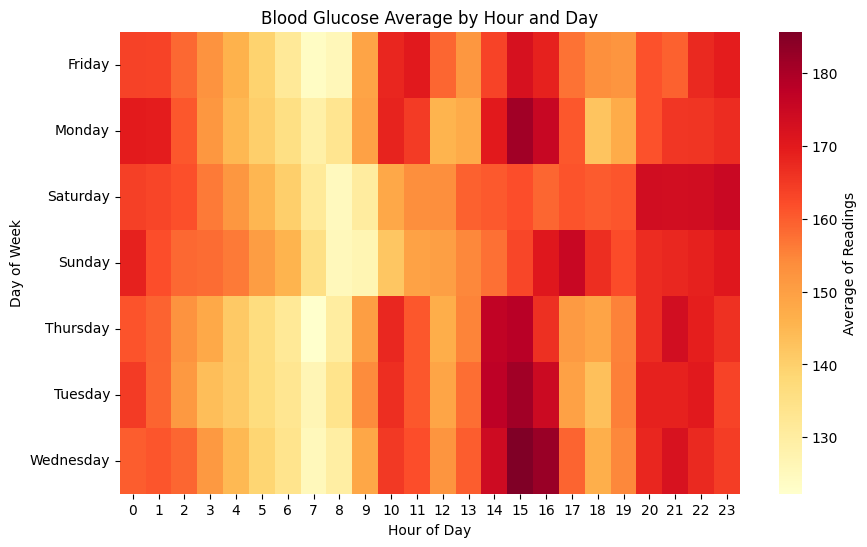

In [29]:
# Create a figure with multiple subplots
plt.figure(figsize=(10, 6))
# 1. Daily glucose distribution
sns.histplot(data=dexcom_df, x='Glucose Value (mg/dL)', bins=30, kde=True)
plt.title('Distribution of Glucose Readings')
plt.xlabel('Glucose Level (mg/dL)')
plt.ylabel('Count')
plt.show()
plt.figure(figsize=(10, 6))
# 2. Box plot by hour of day
dexcom_df['hour'] = dexcom_df['Timestamp'].dt.hour
sns.boxplot(data=dexcom_df, x='hour', y='Glucose Value (mg/dL)')
plt.title('Glucose Levels by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Glucose Level (mg/dL)')
plt.show()
plt.figure(figsize=(10, 6))
# 4. Heatmap of readings by hour and day of week
dexcom_df['day_of_week'] = dexcom_df['Timestamp'].dt.day_name()
pivot_table = dexcom_df.pivot_table(
    index='day_of_week',
    columns='hour',
    values='Glucose Value (mg/dL)',
    aggfunc='mean'
)
sns.heatmap(pivot_table, cmap='YlOrRd', cbar_kws={'label': 'Average of Readings'})
plt.title('Blood Glucose Average by Hour and Day')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

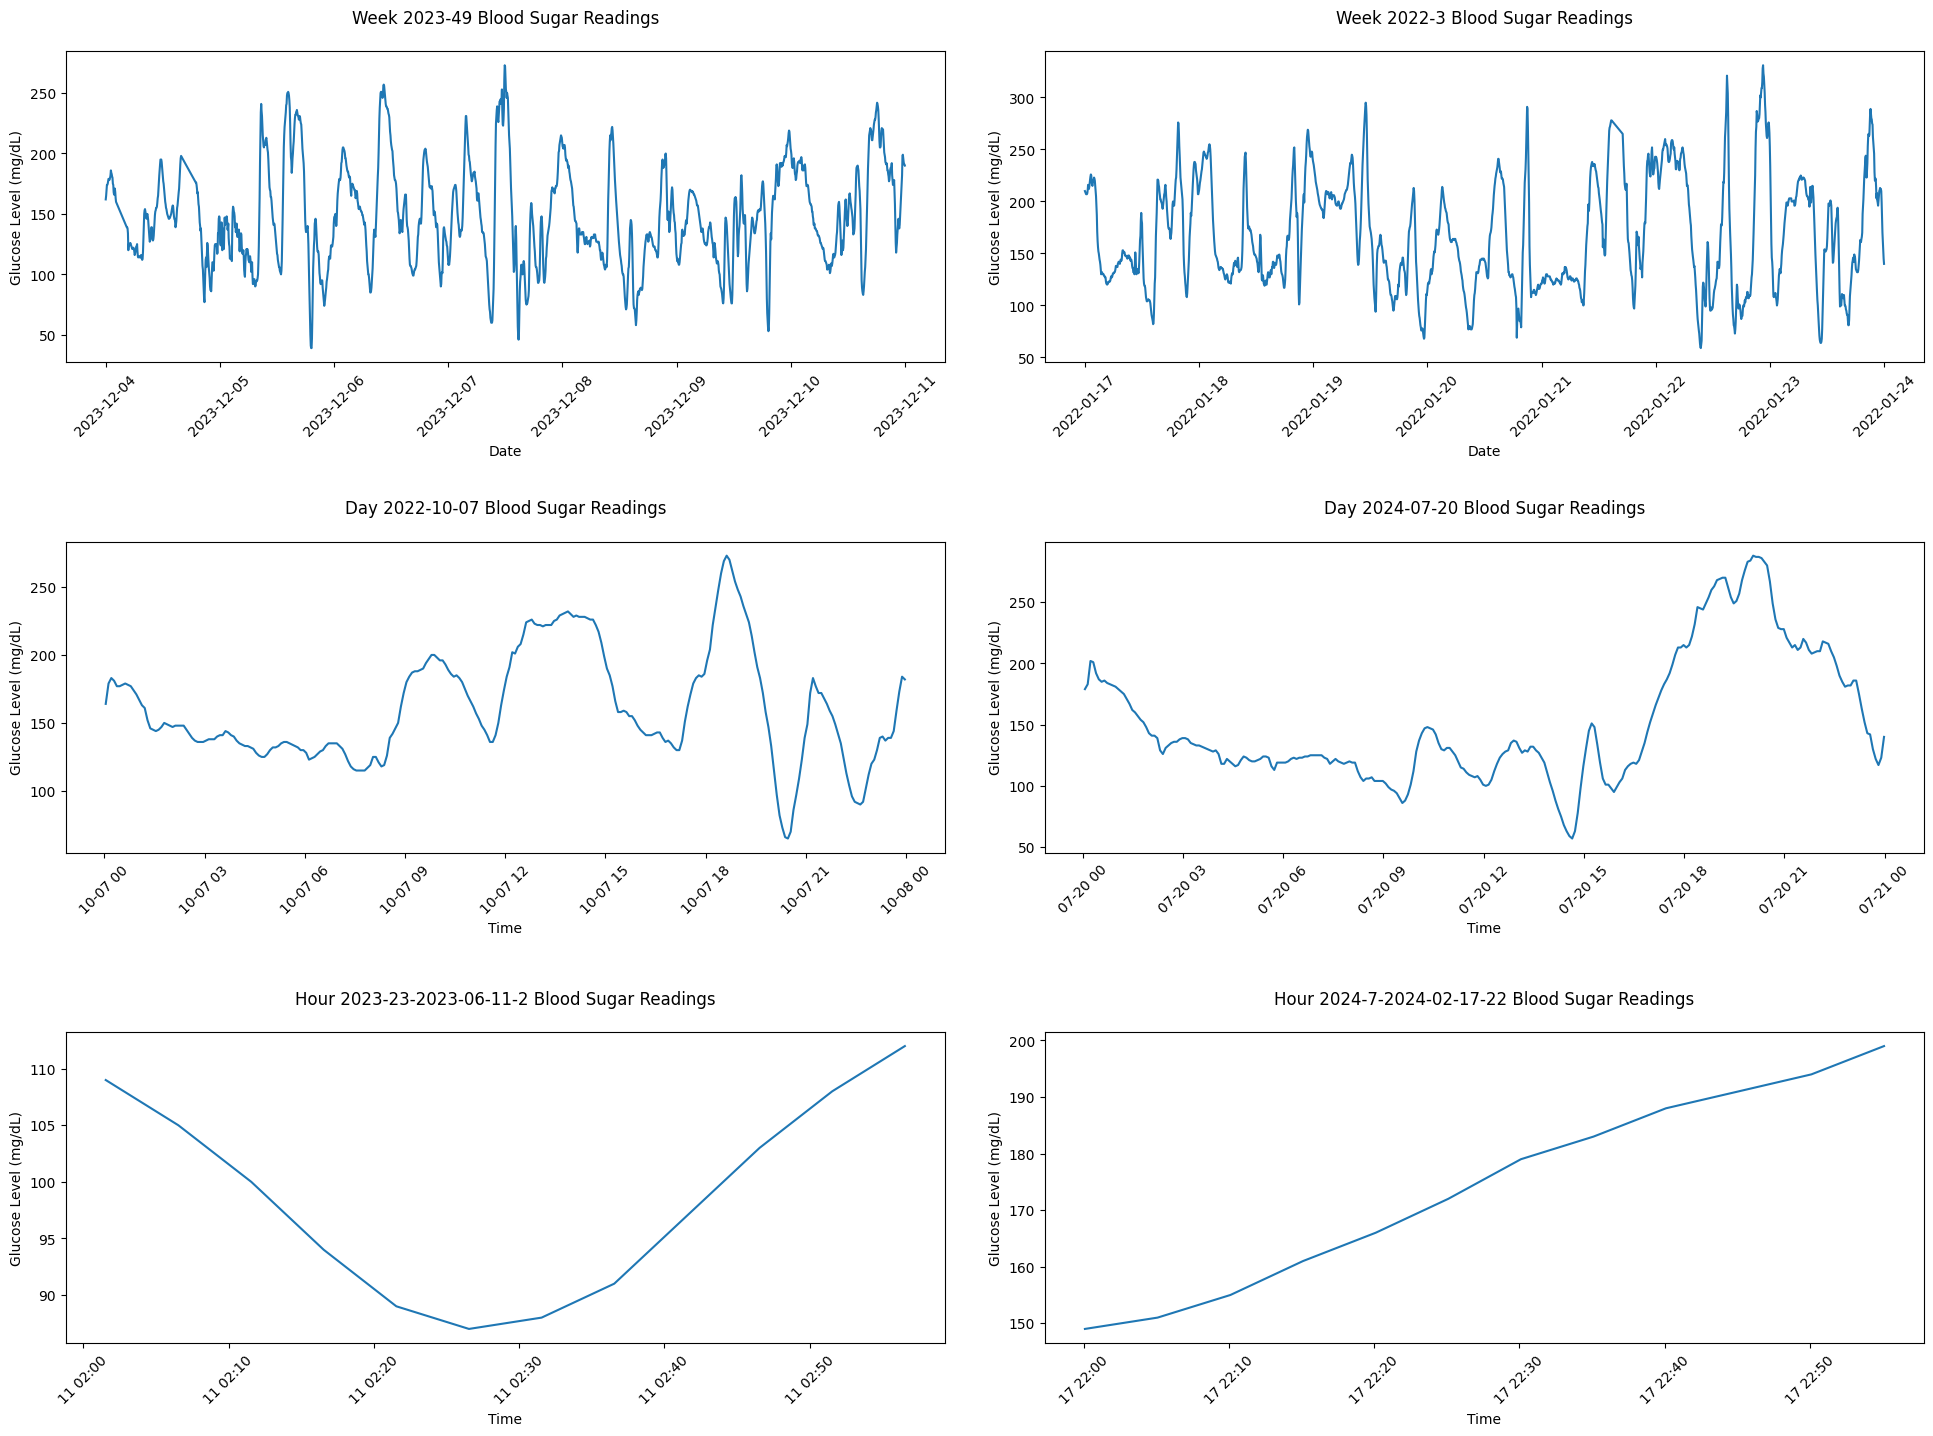


=== Selected Random Samples ===
Selected weeks: ['2023-49' '2022-3']
Selected days: [datetime.date(2022, 10, 7) datetime.date(2024, 7, 20)]
Selected hours: ['2023-23-2023-06-11-2' '2024-7-2024-02-17-22']


In [58]:
np.random.seed(42)

# Create figure with subplots
fig = plt.figure(figsize=(20, 15))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

# Get random samples
dexcom_df['year'] = dexcom_df['Timestamp'].dt.year
dexcom_df['week'] = dexcom_df['Timestamp'].dt.isocalendar().week
dexcom_df['date'] = dexcom_df['Timestamp'].dt.date
dexcom_df['hour'] = dexcom_df['Timestamp'].dt.hour

dexcom_df['year_week'] = dexcom_df['year'].astype(str) + '-' + dexcom_df['week'].astype(str)
dexcom_df['year_week_day_hour'] = dexcom_df['year_week'].astype(str) + '-' + dexcom_df['date'].astype(str) + '-' + dexcom_df['hour'].astype(str)

unique_weeks = dexcom_df['year_week'].unique()
unique_days = dexcom_df['date'].unique()
unique_hours = dexcom_df['year_week_day_hour'].unique()

random_weeks = np.random.choice(unique_weeks, size=2, replace=False)
random_days = np.random.choice(unique_days, size=2, replace=False)
random_hours = np.random.choice(unique_hours, size=2, replace=False)

# 1. Week plots
week_data = dexcom_df[dexcom_df['year_week'].isin(random_weeks)]
for i, week in enumerate(random_weeks):
    plt.subplot(3, 2, i+1)
    week_subset = week_data[week_data['year_week'] == week]
    sns.lineplot(data=week_subset, x='Timestamp', y='Glucose Value (mg/dL)')
    plt.title(f'Week {week} Blood Sugar Readings', pad=20)
    plt.xlabel('Date')
    plt.ylabel('Glucose Level (mg/dL)')
    plt.xticks(rotation=45)

# 2. Day plots
day_data = dexcom_df[dexcom_df['date'].isin(random_days)]
for i, day in enumerate(random_days):
    plt.subplot(3, 2, i+3)
    day_subset = day_data[day_data['date'] == day]
    sns.lineplot(data=day_subset, x='Timestamp', y='Glucose Value (mg/dL)')
    plt.title(f'Day {day} Blood Sugar Readings', pad=20)
    plt.xlabel('Time')
    plt.ylabel('Glucose Level (mg/dL)')
    plt.xticks(rotation=45)

# 3. Hour plots
hour_data = dexcom_df[dexcom_df['year_week_day_hour'].isin(random_hours)]
for i, hour in enumerate(random_hours):
    plt.subplot(3, 2, i+5)
    hour_subset = hour_data[hour_data['year_week_day_hour'] == hour]
    sns.lineplot(data=hour_subset, x='Timestamp', y='Glucose Value (mg/dL)')
    plt.title(f'Hour {hour} Blood Sugar Readings', pad=20)
    plt.xlabel('Time')
    plt.ylabel('Glucose Level (mg/dL)')
    plt.xticks(rotation=45)

# Adjust layout and save
plt.tight_layout(pad=3.0)
plt.show()

# Print information about the selected samples
print("\n=== Selected Random Samples ===")
print(f"Selected weeks: {random_weeks}")
print(f"Selected days: {random_days}")
print(f"Selected hours: {random_hours}")

#### Clustering by Weeks

In [219]:
# Group by week using pd.Grouper
weekly_counts = dexcom_df.groupby(pd.Grouper(key='Timestamp', freq='W')).size()

count_distribution_week = weekly_counts.value_counts().sort_index()

print("Number of readings per day: Number of days with that many readings")
print("-----------------------------------------------------------")
for readings, weeks in count_distribution_week.items():
    print(f"{readings} readings: {weeks} weeks")

Number of readings per day: Number of days with that many readings
-----------------------------------------------------------
0 readings: 11 weeks
158 readings: 1 weeks
320 readings: 2 weeks
417 readings: 1 weeks
542 readings: 1 weeks
659 readings: 1 weeks
675 readings: 1 weeks
814 readings: 1 weeks
823 readings: 1 weeks
919 readings: 1 weeks
1108 readings: 1 weeks
1225 readings: 1 weeks
1254 readings: 1 weeks
1405 readings: 1 weeks
1431 readings: 1 weeks
1442 readings: 1 weeks
1511 readings: 1 weeks
1528 readings: 1 weeks
1557 readings: 1 weeks
1569 readings: 1 weeks
1587 readings: 1 weeks
1600 readings: 1 weeks
1619 readings: 1 weeks
1664 readings: 1 weeks
1665 readings: 1 weeks
1675 readings: 1 weeks
1696 readings: 1 weeks
1699 readings: 1 weeks
1704 readings: 1 weeks
1712 readings: 1 weeks
1714 readings: 1 weeks
1737 readings: 1 weeks
1788 readings: 1 weeks
1813 readings: 1 weeks
1815 readings: 1 weeks
1817 readings: 1 weeks
1823 readings: 1 weeks
1837 readings: 1 weeks
1838 readi

In [11]:
dexcom_df['week_end'] = dexcom_df['Timestamp'].dt.to_period('W').apply(lambda r: r.end_time)

weekly_counts = dexcom_df.groupby('week_end').size()
print(weekly_counts)

week_end
2021-09-05 23:59:59.999999999     675
2021-09-12 23:59:59.999999999    1983
2021-09-19 23:59:59.999999999    1986
2021-09-26 23:59:59.999999999     814
2021-10-03 23:59:59.999999999    2016
                                 ... 
2025-02-02 23:59:59.999999999    1914
2025-02-09 23:59:59.999999999    1992
2025-02-16 23:59:59.999999999    1885
2025-02-23 23:59:59.999999999    2016
2025-03-02 23:59:59.999999999    1968
Length: 172, dtype: int64


In [221]:
low_count_weeks = weekly_counts[weekly_counts < 1700].index

In [222]:
dexcom_df_week = dexcom_df[~dexcom_df['week_end'].isin(low_count_weeks)]

In [223]:
weekly_groups = dexcom_df_week.groupby(pd.Grouper(key='Timestamp', freq='W'))

weekly_series = [group['Glucose Value (mg/dL)'].values
                 for _, group in weekly_groups if not group.empty]

In [225]:
max_length = max(len(series) for series in weekly_series)

padded_series = []
for series in weekly_series:
    padded = np.pad(series, (0, max_length - len(series)), mode='edge')
    padded_series.append(padded)

data_array = np.array(padded_series)
data_array = data_array[..., np.newaxis]  # Add a feature dimension

print("Shape of data_array:", data_array.shape)

Shape of data_array: (144, 2028, 1)


In [226]:
normalized_data_week = []
scaler = MinMaxScaler()
for series in data_array:
    normalized_series = scaler.fit_transform(series)
    normalized_data_week.append(normalized_series)
normalized_data_week = np.array(normalized_data_week)

Clusters: 2, Silhouette Score: 0.119361746562399
Clusters: 3, Silhouette Score: 0.07189924353661697
Clusters: 4, Silhouette Score: 0.018235463407992425
Clusters: 5, Silhouette Score: 0.007313531149183598


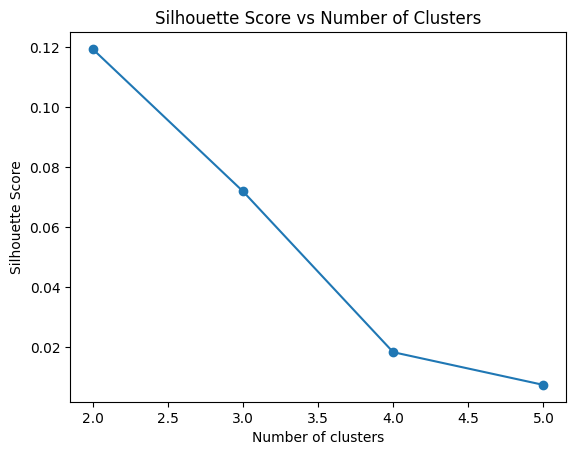

In [229]:
distance_matrix = cdist_dtw(normalized_data_week)

silhouette_scores = []
n_clusters_range = range(2, 6)

for n_clusters in n_clusters_range:
    kmeans = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=0)
    clusters = kmeans.fit_predict(normalized_data_week)
    
    score = silhouette_score(distance_matrix, clusters, metric="precomputed")
    silhouette_scores.append(score)
    print(f'Clusters: {n_clusters}, Silhouette Score: {score}')

plt.plot(list(n_clusters_range), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.show()


#### Clustering by Days

In [233]:
daily_counts = dexcom_df.groupby(pd.Grouper(key='Timestamp', freq='D')).size()

In [234]:
count_distribution = daily_counts.value_counts().sort_index()

print("Number of readings per day: Number of days with that many readings")
print("-----------------------------------------------------------")
for readings, days in count_distribution.items():
    print(f"{readings} readings: {days} days")


Number of readings per day: Number of days with that many readings
-----------------------------------------------------------
0 readings: 136 days
2 readings: 1 days
3 readings: 1 days
17 readings: 1 days
32 readings: 2 days
60 readings: 1 days
71 readings: 1 days
76 readings: 1 days
82 readings: 1 days
87 readings: 1 days
91 readings: 1 days
95 readings: 2 days
102 readings: 1 days
103 readings: 1 days
106 readings: 1 days
109 readings: 1 days
117 readings: 1 days
120 readings: 1 days
121 readings: 1 days
124 readings: 1 days
128 readings: 1 days
129 readings: 1 days
130 readings: 1 days
131 readings: 1 days
143 readings: 2 days
147 readings: 2 days
150 readings: 1 days
151 readings: 1 days
154 readings: 2 days
155 readings: 2 days
158 readings: 1 days
159 readings: 1 days
161 readings: 1 days
162 readings: 2 days
165 readings: 1 days
174 readings: 1 days
182 readings: 1 days
184 readings: 1 days
186 readings: 1 days
188 readings: 2 days
190 readings: 1 days
194 readings: 1 days
198 

In [235]:
low_count_days = daily_counts[daily_counts < 200].index
dexcom_df_day = dexcom_df[~dexcom_df['Timestamp'].dt.date.isin(low_count_days)]

In [236]:
daily_groups = dexcom_df_day.groupby(pd.Grouper(key='Timestamp', freq='D'))

daily_series = [group['Glucose Value (mg/dL)'].values
                for _, group in daily_groups if not group.empty]

max_length = max(len(series) for series in daily_series)
padded_series = []
for series in daily_series:
    padded = np.pad(series, (0, max_length - len(series)), mode='edge')
    padded_series.append(padded)

data_array = np.array(padded_series)
data_array = data_array[..., np.newaxis]  # Add a feature dimension

print("Shape of data_array:", data_array.shape)
print("1144 days, 578 glucose values, 1 feature (time series thing)")

# Normalize the data
normalized_data_day = []
scaler = MinMaxScaler()
for series in data_array:
    normalized_series = scaler.fit_transform(series)
    normalized_data_day.append(normalized_series)
normalized_data_day = np.array(normalized_data_day)


Shape of data_array: (1141, 300, 1)
1144 days, 578 glucose values, 1 feature (time series thing)


Clusters: 2, Silhouette Score: 0.21814427332459269
Clusters: 3, Silhouette Score: 0.19565800483947757
Clusters: 4, Silhouette Score: 0.1578311194115137
Clusters: 5, Silhouette Score: 0.14155905588003845


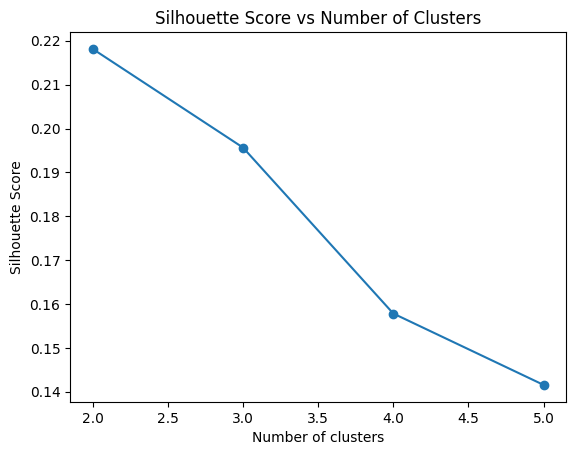

In [237]:
distance_matrix_day = cdist_dtw(normalized_data_day)

silhouette_scores = []
n_clusters_range = range(2, 6)

for n_clusters in n_clusters_range:
    kmeans = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=0)
    clusters = kmeans.fit_predict(normalized_data_day)

    score = silhouette_score(distance_matrix_day, clusters, metric="precomputed")
    silhouette_scores.append(score)
    print(f'Clusters: {n_clusters}, Silhouette Score: {score}')

plt.plot(list(n_clusters_range), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.show()

#### Clustering by Hours

In [9]:
hourly_counts = dexcom_df.groupby([dexcom_df['Timestamp'].dt.date, 
                                   dexcom_df['Timestamp'].dt.hour]).size()

wrong_count_hours = hourly_counts[hourly_counts != 12].index

dexcom_df['date_hour'] = list(zip(dexcom_df['Timestamp'].dt.date, dexcom_df['Timestamp'].dt.hour))

dexcom_df_hours = dexcom_df[~dexcom_df['date_hour'].isin(wrong_count_hours)]

In [10]:
hourly_groups = dexcom_df_hours.groupby([dexcom_df['Timestamp'].dt.date, 
                                   dexcom_df['Timestamp'].dt.hour])

hourly_series = [group['Glucose Value (mg/dL)'].values
                for _, group in hourly_groups if not group.empty]

max_length = max(len(series) for series in hourly_series)
padded_series = []
for series in hourly_series:
    padded = np.pad(series, (0, max_length - len(series)), mode='edge')
    padded_series.append(padded)

data_array = np.array(padded_series)
data_array = data_array[..., np.newaxis]  # Add a feature dimension

print("Shape of data_array:", data_array.shape)

# Normalize the data
normalized_data_hour = []
scaler = MinMaxScaler()
for series in data_array:
    normalized_series = scaler.fit_transform(series)
    normalized_data_hour.append(normalized_series)
normalized_data_hour = np.array(normalized_data_hour)

Shape of data_array: (25692, 12, 1)


Clusters: 2, Silhouette Score: 0.643112996413028
Clusters: 3, Silhouette Score: 0.5413593281642719
Clusters: 4, Silhouette Score: 0.5579580463663696


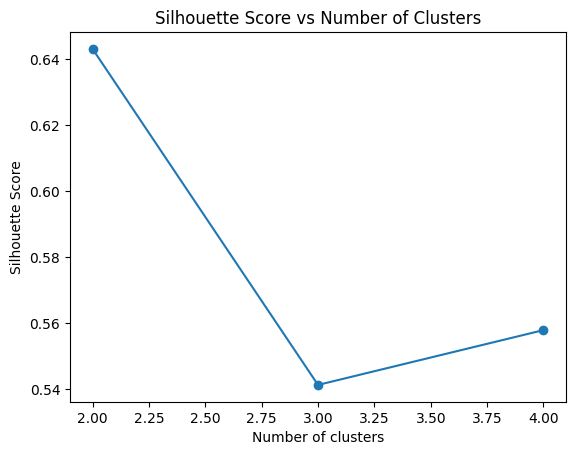

In [10]:
distance_matrix_hour = cdist_dtw(normalized_data_hour)

silhouette_scores = []
n_clusters_range = range(2, 5)

for n_clusters in n_clusters_range:
    kmeans = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=0)
    clusters = kmeans.fit_predict(normalized_data_hour)
    cluster_df = pd.DataFrame({
        'cluster': clusters
    })
    cluster_df.to_csv(f'cluster_assignments_{n_clusters}.csv', index=False)
    score = silhouette_score(distance_matrix_hour, clusters, metric="precomputed")
    silhouette_scores.append(score)
    print(f'Clusters: {n_clusters}, Silhouette Score: {score}')

plt.plot(list(n_clusters_range), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.show()

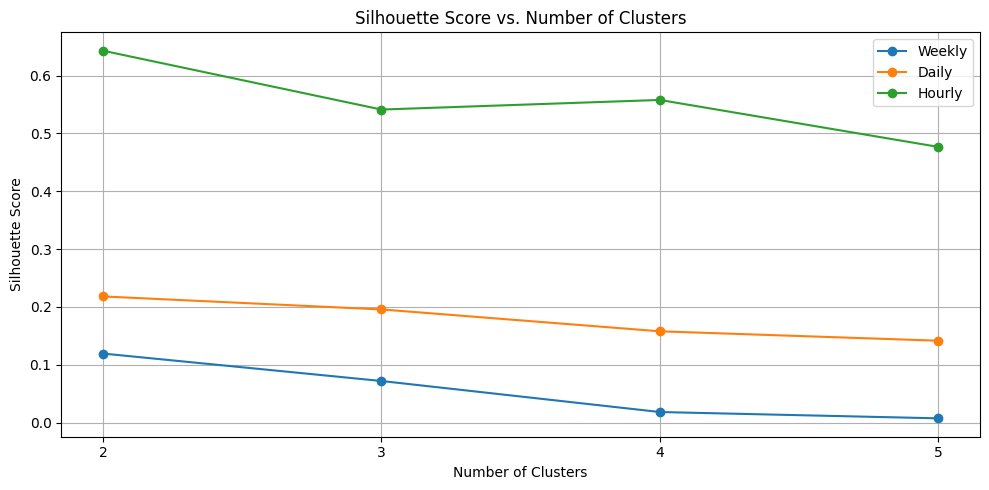

In [60]:
# Cluster counts (x-axis)
clusters = [2, 3, 4, 5]

# Silhouette scores for each time range
weekly_scores = [0.11936, 0.07190, 0.01824, 0.00731]
daily_scores =  [0.21814, 0.19566, 0.15783, 0.14156]
hourly_scores = [0.64311, 0.54136, 0.55796, 0.47677]

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(clusters, weekly_scores, marker='o', label='Weekly')
plt.plot(clusters, daily_scores, marker='o', label='Daily')
plt.plot(clusters, hourly_scores, marker='o', label='Hourly')

# Labels and title
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xticks(clusters)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Visualizing Clustering

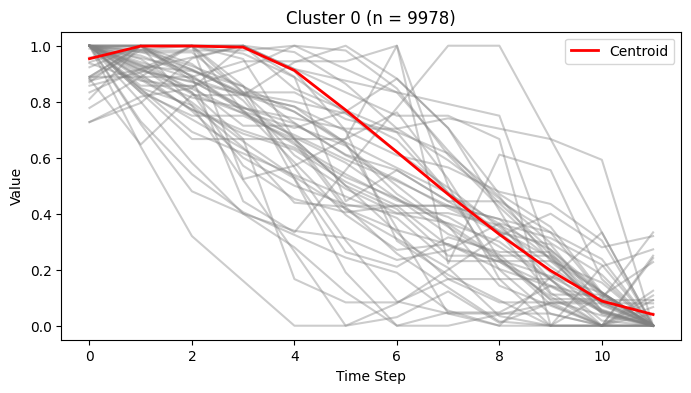

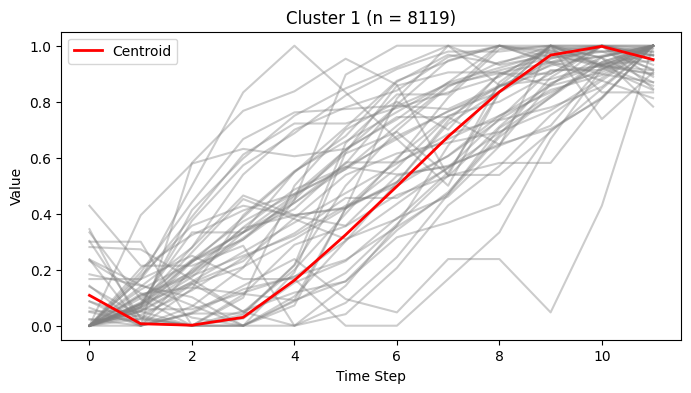

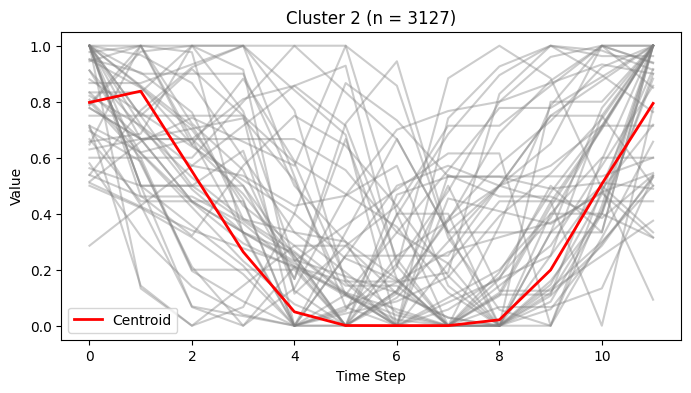

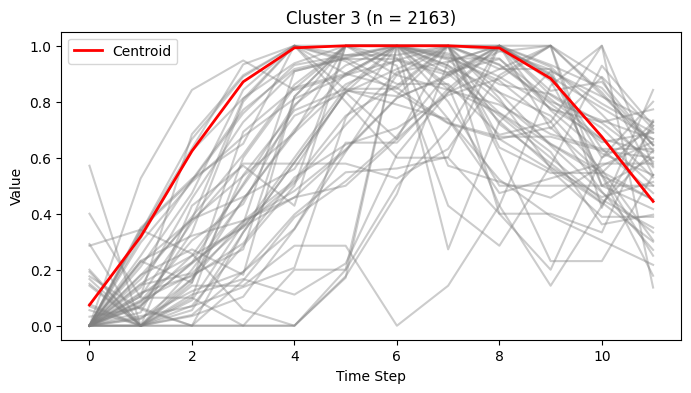

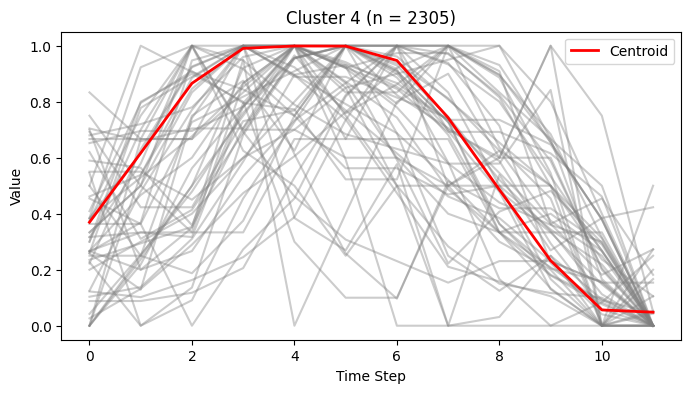

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

centroids = kmeans.cluster_centers_

n_clusters = kmeans.n_clusters

for i in range(n_clusters):
    plt.figure(figsize=(8, 4))
    
    cluster_ts = normalized_data_hour[clusters == i]
    
    for ts in cluster_ts[:50]:
        plt.plot(ts.ravel(), color='gray', alpha=0.4)
    
    # Plot the cluster centroid in red
    plt.plot(centroids[i].ravel(), color='red', linewidth=2, label="Centroid")
    
    plt.title(f"Cluster {i} (n = {len(cluster_ts)})")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

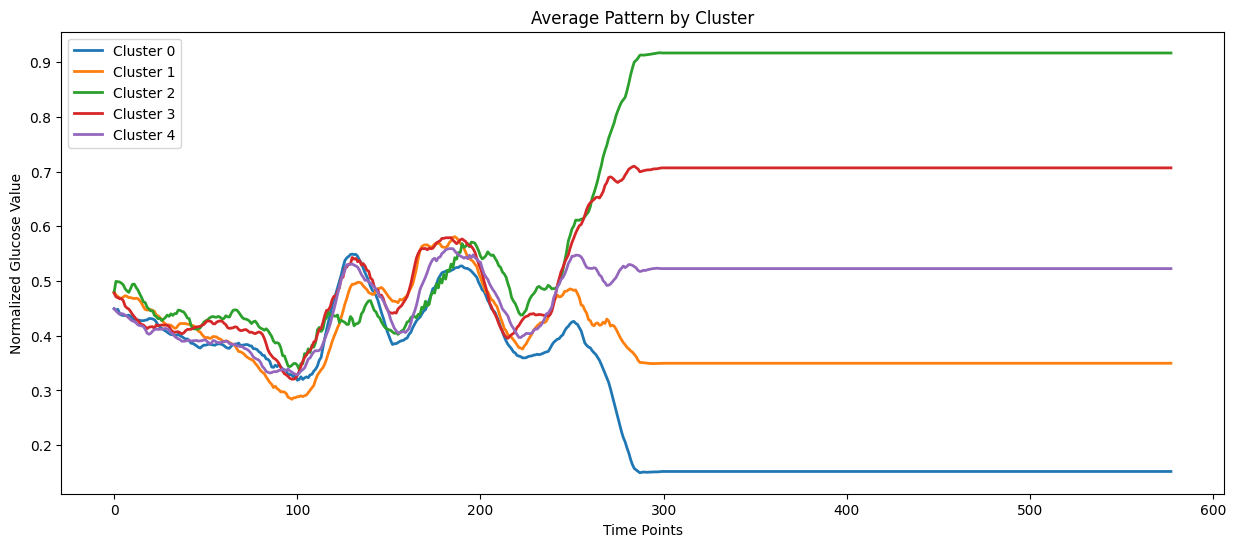

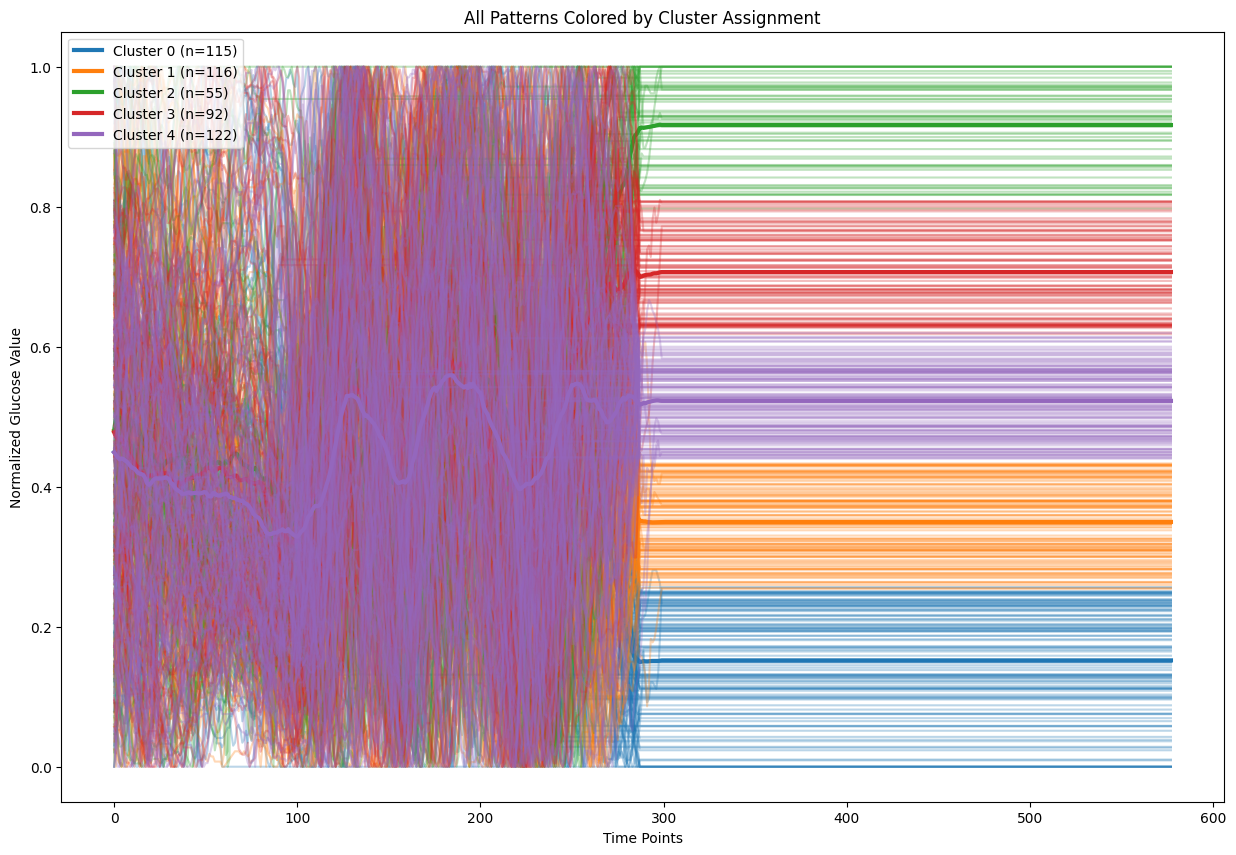

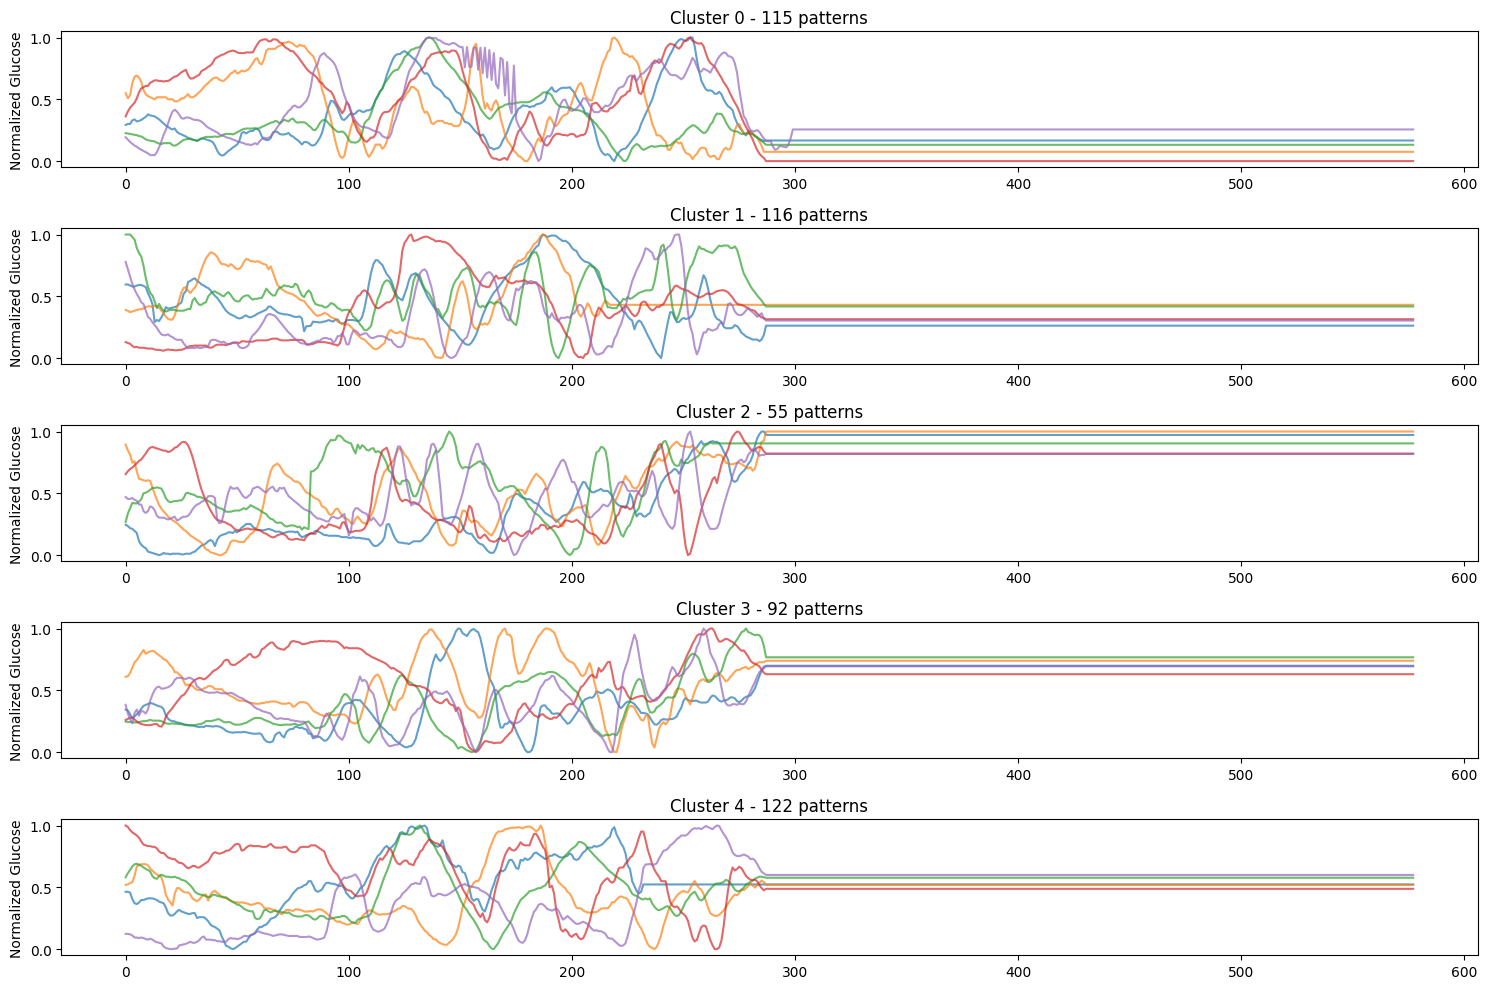

In [60]:
# 1. Plot average pattern for each cluster
plt.figure(figsize=(15, 6))
for i in range(kmeans.n_clusters):
    # Get all samples in this cluster
    cluster_samples = normalized_data_week[clusters == i]
    
    # Calculate mean pattern
    mean_pattern = np.mean(cluster_samples, axis=0)
    
    # Plot mean pattern
    plt.plot(mean_pattern, label=f'Cluster {i}', linewidth=2)

plt.title('Average Pattern by Cluster')
plt.xlabel('Time Points')
plt.ylabel('Normalized Glucose Value')
plt.legend()
plt.show()

# 3. Optional: Plot a few random examples from each cluster
plt.figure(figsize=(15, 10))
n_examples = 5  # number of examples to show from each cluster

for i in range(kmeans.n_clusters):
    plt.subplot(kmeans.n_clusters, 1, i+1)
    
    # Get samples in this cluster
    cluster_samples = normalized_data_week[clusters == i]
    
    # Randomly select n_examples
    if len(cluster_samples) > n_examples:
        random_indices = np.random.choice(len(cluster_samples), n_examples, replace=False)
        examples = cluster_samples[random_indices]
    else:
        examples = cluster_samples
    
    # Plot examples
    for sample in examples:
        plt.plot(sample, alpha=0.7)
    
    plt.title(f'Cluster {i} - {len(cluster_samples)} patterns')
    plt.ylabel('Normalized Glucose')

plt.tight_layout()
plt.show()

### Clustering Analysis and Dimension Reduction (PCA/UMAP)

In [12]:
two_clusters = pd.read_csv('cluster_assignments_2.csv')['cluster'].tolist()
three_clusters = pd.read_csv('cluster_assignments_3.csv')['cluster'].tolist()
four_clusters = pd.read_csv('cluster_assignments_4.csv')['cluster'].tolist()

In [13]:
normalized_data_hour.shape

(25692, 12, 1)

In [14]:
two_clusters.shape

(25692, 1)

In [13]:
date_time = dexcom_df_hours['date_hour'].unique().tolist()

In [14]:
df_hourly = pd.DataFrame({
    'date_hour': date_time,
    **{f'value_{i+1}': [series[i] for series in hourly_series] for i in range(12)},
    'two_cluster': two_clusters,
    'three_cluster': three_clusters,
    'four_cluster': four_clusters
})

In [15]:
X = df_hourly.drop(['date_hour', 'two_cluster', 'three_cluster', 'four_cluster'], axis=1)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame with PCA results
df_pca = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X.shape[1])]
)

In [26]:
df_hourly_scaled = pd.DataFrame({
    'date_hour': date_time,
    **{f'value_{i+1}': [series[i] for series in X_scaled.tolist()] for i in range(12)},
    'two_cluster': two_clusters,
    'three_cluster': three_clusters,
    'four_cluster': four_clusters
})

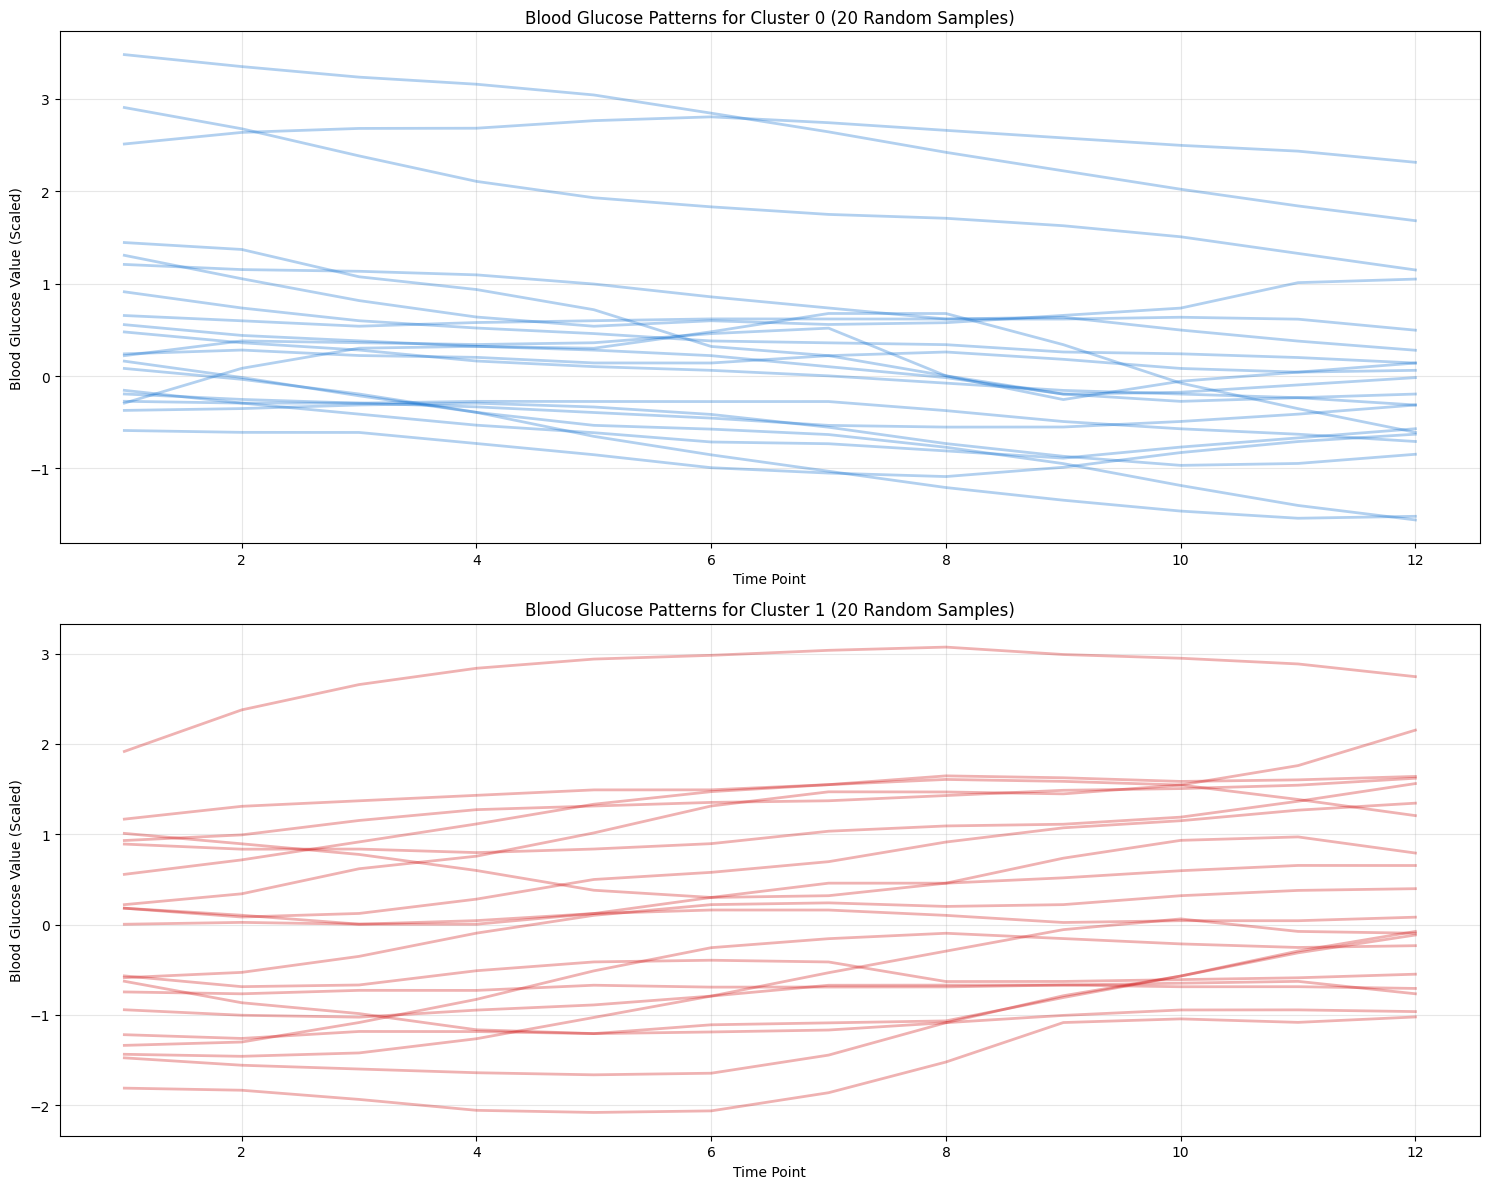

In [64]:
# Create value column names
value_cols = [f'value_{i}' for i in range(1, 13)]

# Randomly select 50 rows from each cluster
cluster_0_rows = df_hourly_scaled[df_hourly_scaled['two_cluster'] == 0].sample(n=20)
cluster_1_rows = df_hourly_scaled[df_hourly_scaled['two_cluster'] == 1].sample(n=20)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Plot cluster 0 rows
for idx, row in cluster_0_rows.iterrows():
    values = row[value_cols].values
    ax1.plot(range(1, 13), values, color='#0066CC', linewidth=2, alpha=0.3)

# Plot cluster 1 rows
for idx, row in cluster_1_rows.iterrows():
    values = row[value_cols].values
    ax2.plot(range(1, 13), values, color='#CC0000', linewidth=2, alpha=0.3)

# Customize the plots
for ax, cluster_num in [(ax1, 0), (ax2, 1)]:
    ax.set_xlabel('Time Point')
    ax.set_ylabel('Blood Glucose Value (Scaled)')
    ax.set_title(f'Blood Glucose Patterns for Cluster {cluster_num} (20 Random Samples)')
    ax.grid(True, alpha=0.3)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

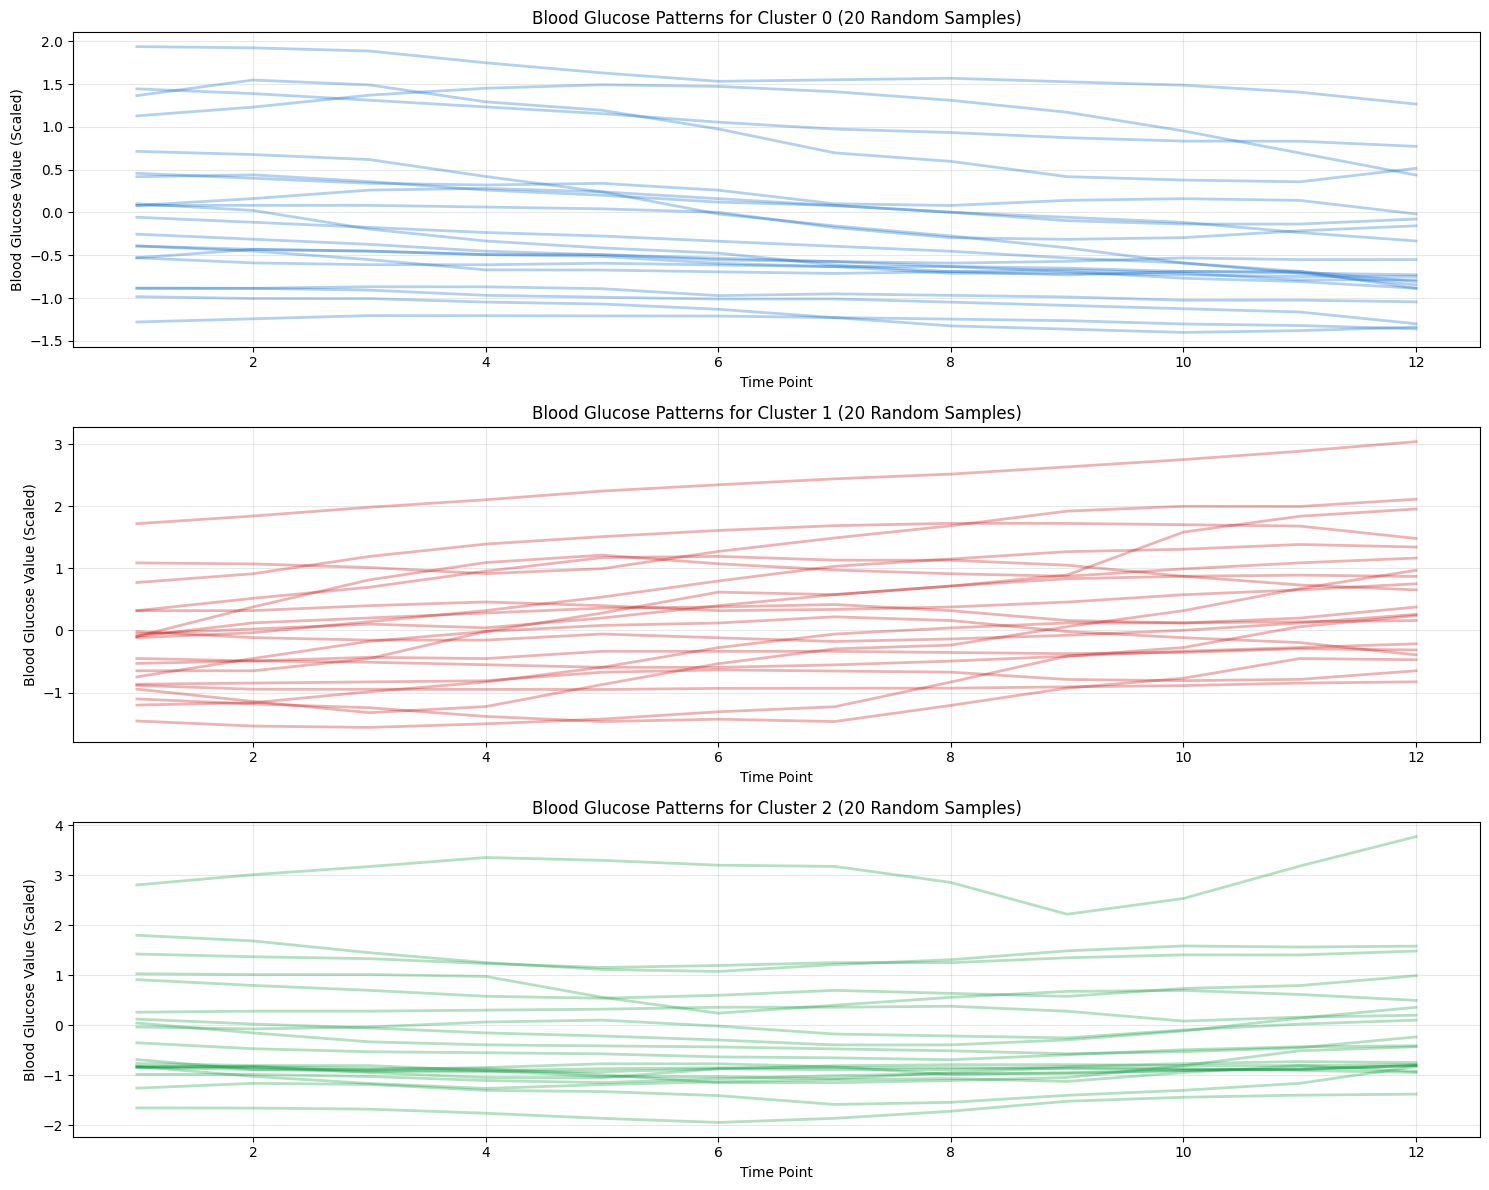

In [65]:
# Create value column names
value_cols = [f'value_{i}' for i in range(1, 13)]

# Randomly select 50 rows from each cluster
cluster_0_rows = df_hourly_scaled[df_hourly_scaled['three_cluster'] == 0].sample(n=20)
cluster_1_rows = df_hourly_scaled[df_hourly_scaled['three_cluster'] == 1].sample(n=20)
cluster_2_rows = df_hourly_scaled[df_hourly_scaled['three_cluster'] == 2].sample(n=20)

# Create figure with two subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))

# Plot cluster 0 rows
for idx, row in cluster_0_rows.iterrows():
    values = row[value_cols].values
    ax1.plot(range(1, 13), values, color='#0066CC', linewidth=2, alpha=0.3)

# Plot cluster 1 rows
for idx, row in cluster_1_rows.iterrows():
    values = row[value_cols].values
    ax2.plot(range(1, 13), values, color='#CC0000', linewidth=2, alpha=0.3)

# Plot cluster 2 rows
for idx, row in cluster_2_rows.iterrows():
    values = row[value_cols].values
    ax3.plot(range(1, 13), values, color='#009933', linewidth=2, alpha=0.3)

# Customize the plots
for ax, cluster_num in [(ax1, 0), (ax2, 1), (ax3, 2)]:
    ax.set_xlabel('Time Point')
    ax.set_ylabel('Blood Glucose Value (Scaled)')
    ax.set_title(f'Blood Glucose Patterns for Cluster {cluster_num} (20 Random Samples)')
    ax.grid(True, alpha=0.3)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

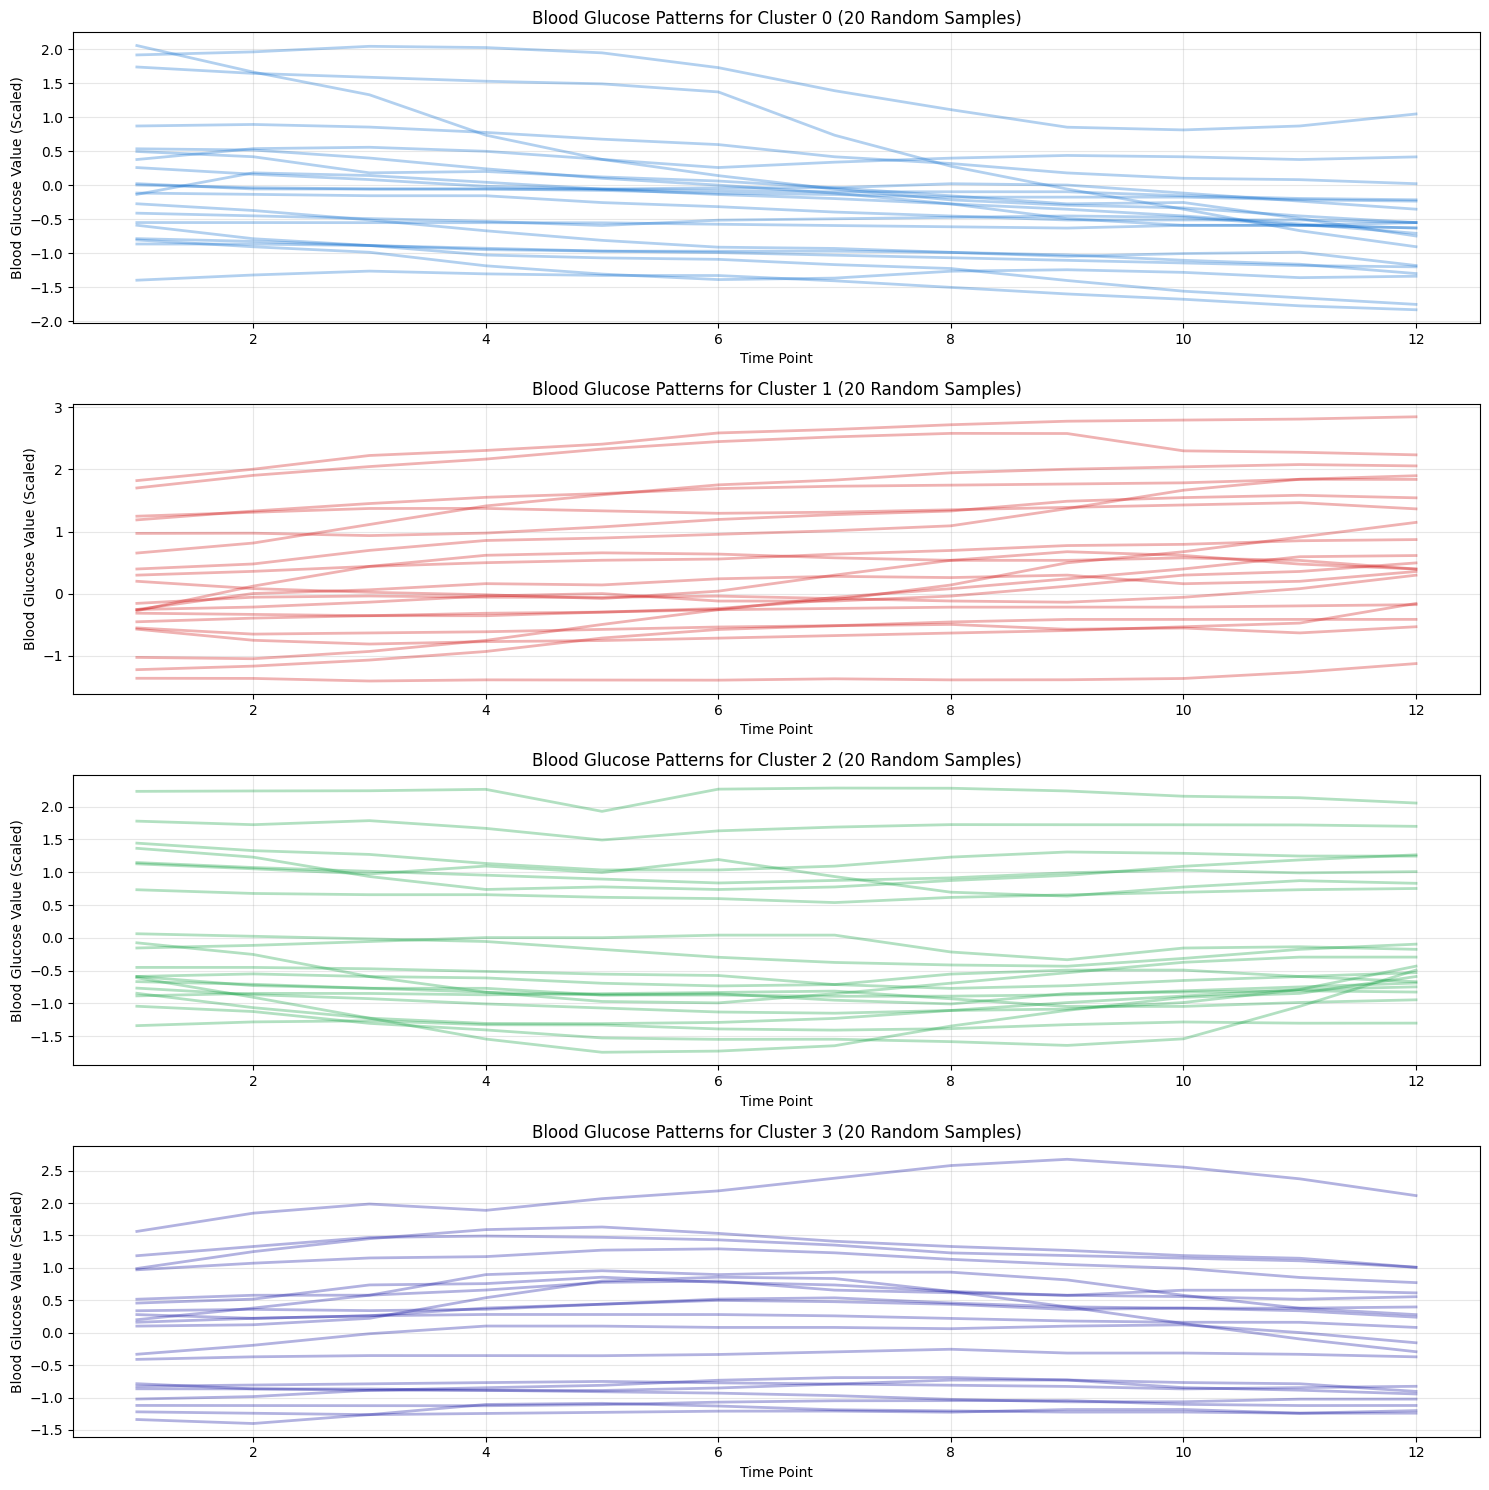

In [66]:
# Create value column names
value_cols = [f'value_{i}' for i in range(1, 13)]

# Randomly select 50 rows from each cluster
cluster_0_rows = df_hourly_scaled[df_hourly_scaled['four_cluster'] == 0].sample(n=20)
cluster_1_rows = df_hourly_scaled[df_hourly_scaled['four_cluster'] == 1].sample(n=20)
cluster_2_rows = df_hourly_scaled[df_hourly_scaled['four_cluster'] == 2].sample(n=20)
cluster_3_rows = df_hourly_scaled[df_hourly_scaled['four_cluster'] == 3].sample(n=20)

# Create figure with two subplots
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 15))

# Plot cluster 0 rows
for idx, row in cluster_0_rows.iterrows():
    values = row[value_cols].values
    ax1.plot(range(1, 13), values, color='#0066CC', linewidth=2, alpha=0.3)

# Plot cluster 1 rows
for idx, row in cluster_1_rows.iterrows():
    values = row[value_cols].values
    ax2.plot(range(1, 13), values, color='#CC0000', linewidth=2, alpha=0.3)

# Plot cluster 2 rows
for idx, row in cluster_2_rows.iterrows():
    values = row[value_cols].values
    ax3.plot(range(1, 13), values, color='#009933', linewidth=2, alpha=0.3)

# Plot cluster 3 rows
for idx, row in cluster_3_rows.iterrows():
    values = row[value_cols].values
    ax4.plot(range(1, 13), values, color='#000099', linewidth=2, alpha=0.3)

# Customize the plots
for ax, cluster_num in [(ax1, 0), (ax2, 1), (ax3, 2), (ax4, 3)]:
    ax.set_xlabel('Time Point')
    ax.set_ylabel('Blood Glucose Value (Scaled)')
    ax.set_title(f'Blood Glucose Patterns for Cluster {cluster_num} (20 Random Samples)')
    ax.grid(True, alpha=0.3)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

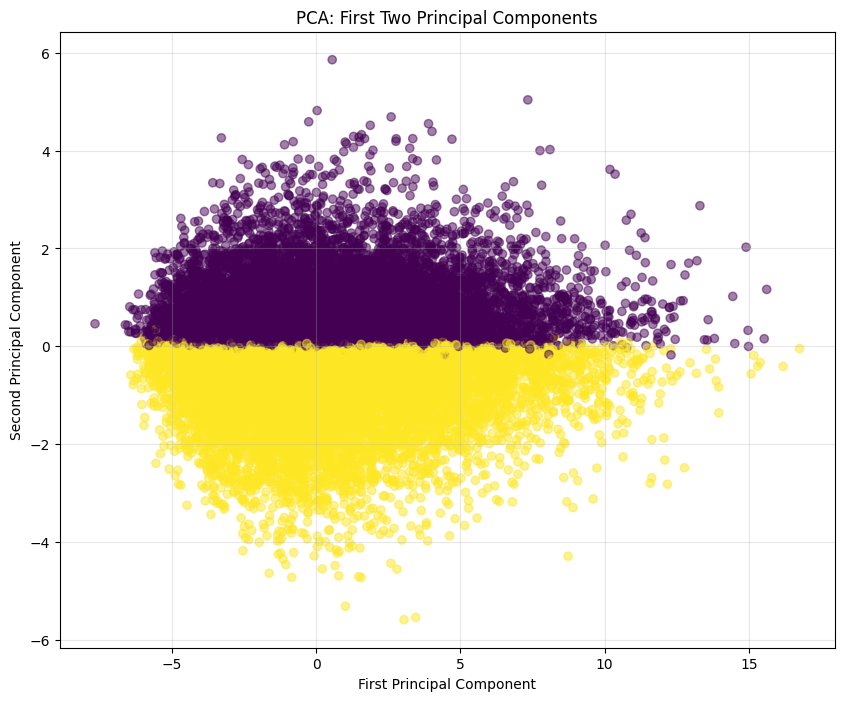

In [58]:
# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_hourly['two_cluster'], alpha=0.5)

# Add labels and title
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA: First Two Principal Components')

# Add grid
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


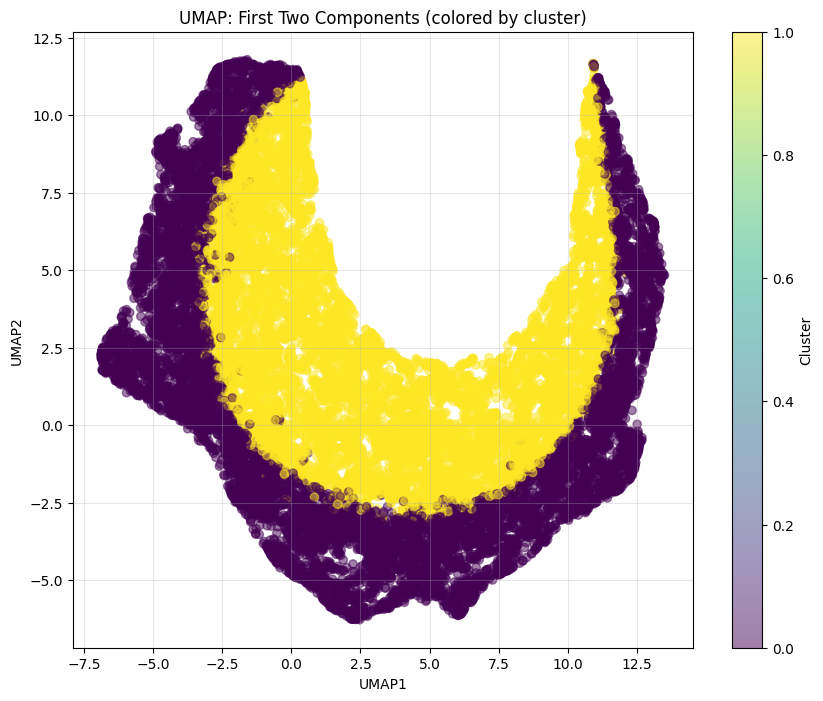

In [68]:
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_scaled)  # Using the same scaled data from PCA

# Create DataFrame with UMAP results
df_umap = pd.DataFrame(
    X_umap,
    columns=['UMAP1', 'UMAP2']
)
df_umap['date_hour'] = df_hourly['date_hour']

# Plot UMAP results colored by clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], 
                     c=df_hourly['two_cluster'], 
                     cmap='viridis',
                     alpha=0.5)

# Add colorbar
plt.colorbar(scatter, label='Cluster')

# Add labels and title
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('UMAP: First Two Components (colored by cluster)')

# Add grid
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

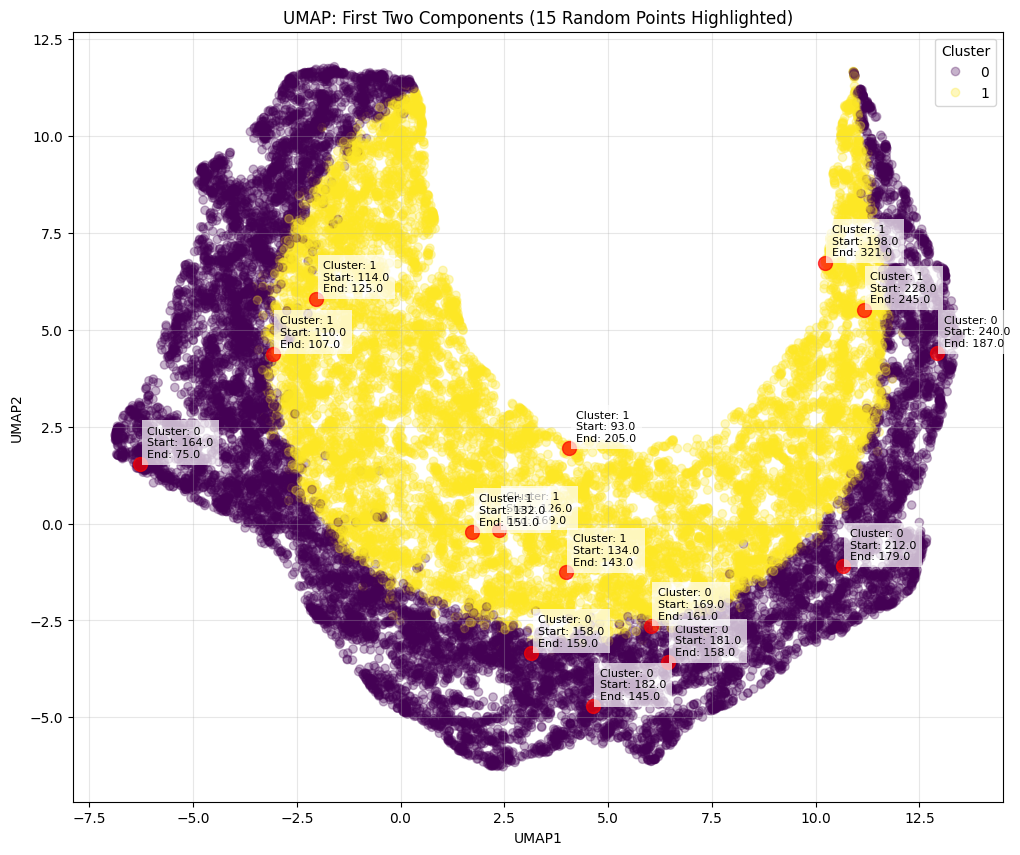


Selected points information:
Date-Hour: (datetime.date(2021, 9, 18), 6), Cluster: 1
Date-Hour: (datetime.date(2021, 11, 4), 4), Cluster: 1
Date-Hour: (datetime.date(2024, 4, 25), 21), Cluster: 0
Date-Hour: (datetime.date(2023, 10, 28), 23), Cluster: 0
Date-Hour: (datetime.date(2023, 9, 14), 19), Cluster: 0
Date-Hour: (datetime.date(2022, 6, 15), 9), Cluster: 1
Date-Hour: (datetime.date(2022, 9, 5), 3), Cluster: 0
Date-Hour: (datetime.date(2021, 9, 20), 18), Cluster: 1
Date-Hour: (datetime.date(2024, 5, 29), 19), Cluster: 0
Date-Hour: (datetime.date(2023, 3, 6), 8), Cluster: 0
Date-Hour: (datetime.date(2023, 10, 2), 2), Cluster: 1
Date-Hour: (datetime.date(2024, 11, 12), 9), Cluster: 1
Date-Hour: (datetime.date(2024, 4, 15), 1), Cluster: 1
Date-Hour: (datetime.date(2025, 2, 19), 18), Cluster: 0
Date-Hour: (datetime.date(2024, 7, 23), 19), Cluster: 1


In [88]:
# Create the base UMAP plot
plt.figure(figsize=(12, 10))
scatter = plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], 
                     c=df_hourly['two_cluster'], 
                     cmap='viridis',
                     alpha=0.3)  # Made other points more transparent
plt.legend(*scatter.legend_elements(),
          title='Cluster',
          loc='upper right',
          bbox_to_anchor=(1, 1))
# Randomly select 20 points
random_indices = np.random.choice(len(df_umap), size=15, replace=False)

# Highlight and annotate the selected points
for idx in random_indices:
    # Plot the point with a different style
    plt.scatter(df_umap['UMAP1'].iloc[idx], 
               df_umap['UMAP2'].iloc[idx],
               c='red',
               s=100,  # Larger size
               alpha=0.7)
    
    value_1 = df_hourly['value_1'].iloc[idx]
    value_12 = df_hourly['value_12'].iloc[idx]
    
    # Add annotation with date_hour and values
    plt.annotate(f"Cluster: {df_hourly['two_cluster'].iloc[idx]}\nStart: {value_1:.1f}\nEnd: {value_12:.1f}",
                (df_umap['UMAP1'].iloc[idx], df_umap['UMAP2'].iloc[idx]),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
                bbox=dict(facecolor='white', 
                         edgecolor='none', 
                         alpha=0.7))


plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('UMAP: First Two Components (15 Random Points Highlighted)')

# Add grid
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

# Print the selected points' information
print("\nSelected points information:")
for idx in random_indices:
    print(f"Date-Hour: {df_umap['date_hour'].iloc[idx]}, "
          f"Cluster: {df_hourly['two_cluster'].iloc[idx]}")

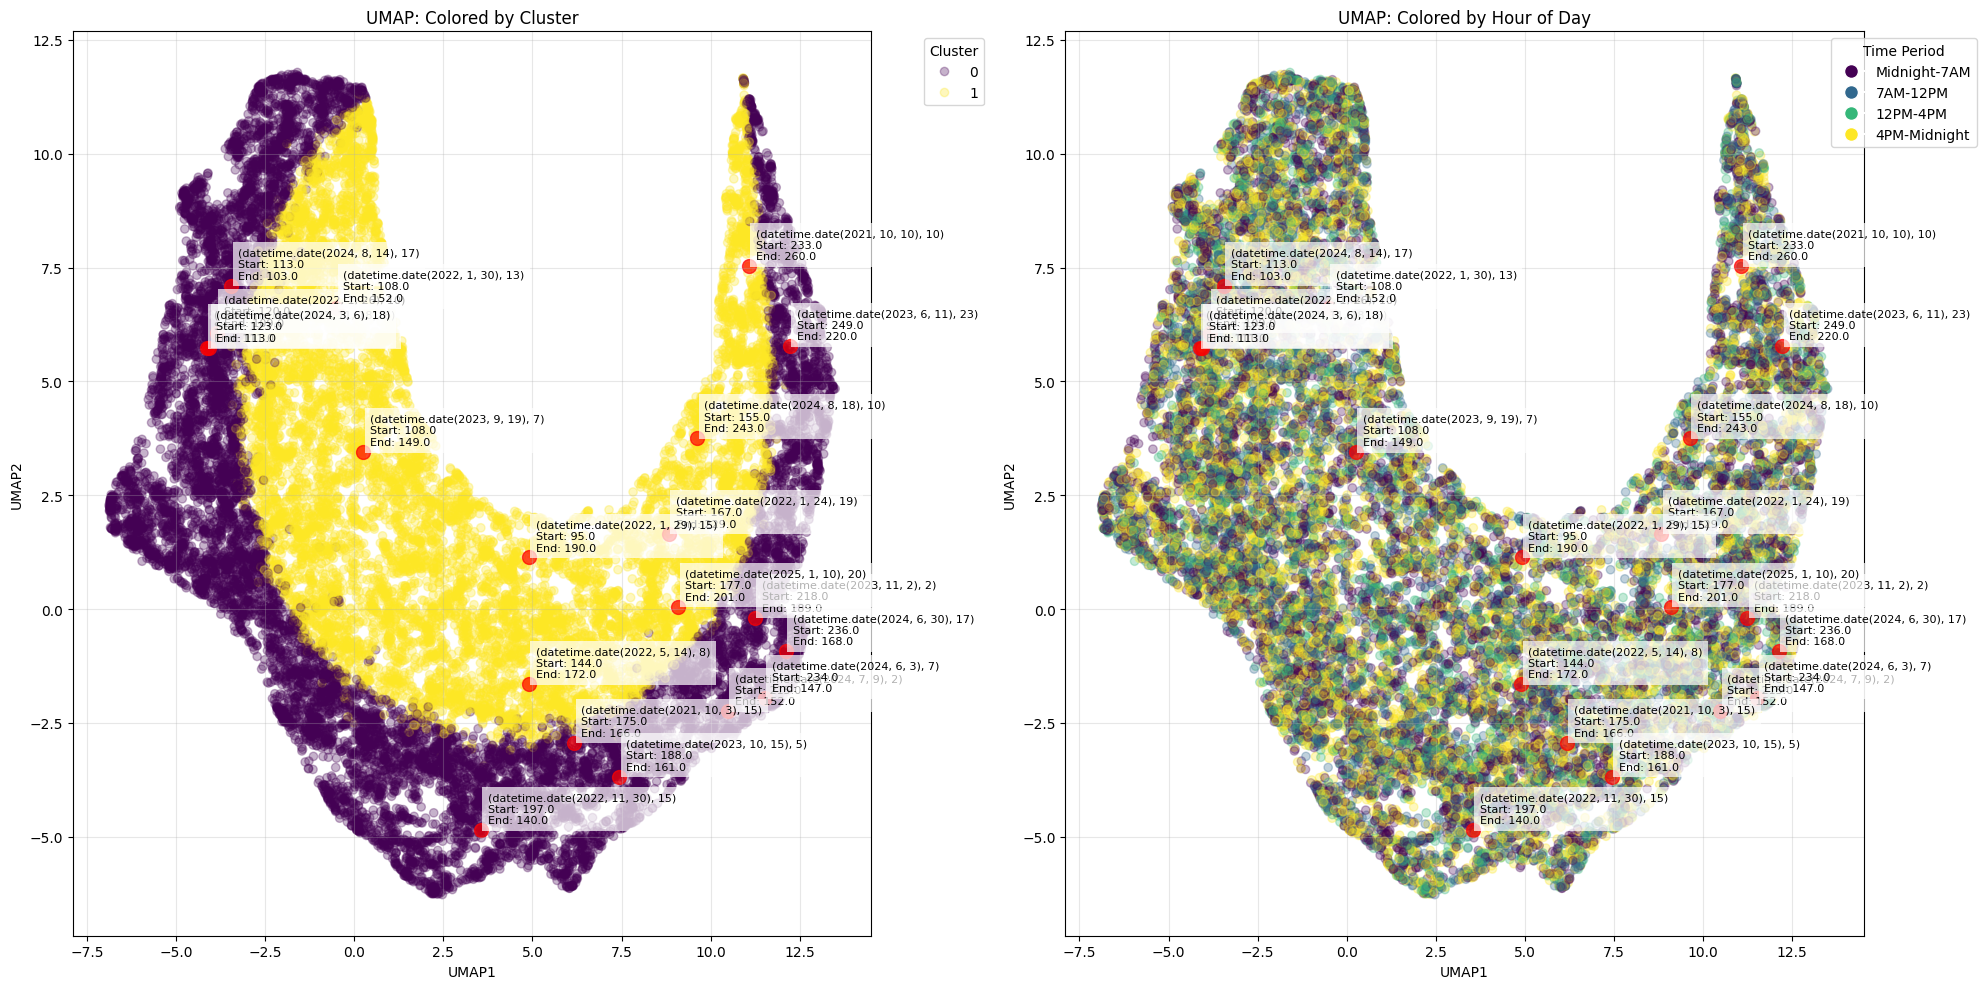

In [90]:
hours = [x[1] for x in df_umap['date_hour']]

def get_time_period(hour):
    if 0 <= hour < 7:
        return 0  # Midnight to 7 AM
    elif 7 <= hour < 12:
        return 1  # 7 AM to 12 PM
    elif 12 <= hour < 16:
        return 2  # 12 PM to 4 PM
    else:
        return 3  # 4 PM to Midnight

time_periods = [get_time_period(h) for h in hours]

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Randomly select 20 points
random_indices = np.random.choice(len(df_umap), size=20, replace=False)

# Plot 1: Colored by cluster
scatter1 = ax1.scatter(df_umap['UMAP1'], df_umap['UMAP2'], 
                      c=df_hourly['two_cluster'], 
                      cmap='viridis',
                      alpha=0.3)
ax1.set_title('UMAP: Colored by Cluster')
ax1.set_xlabel('UMAP1')
ax1.set_ylabel('UMAP2')
ax1.grid(True, alpha=0.3)
ax1.legend(*scatter1.legend_elements(),
          title='Cluster',
          loc='upper right',
          bbox_to_anchor=(1.15, 1))
# Plot 2: Colored by hour
scatter2 = ax2.scatter(df_umap['UMAP1'], df_umap['UMAP2'], 
                      c=time_periods,
                      cmap='viridis',
                      alpha=0.3)
ax2.set_title('UMAP: Colored by Hour of Day')
ax2.set_xlabel('UMAP1')
ax2.set_ylabel('UMAP2')
ax2.grid(True, alpha=0.3)
time_period_labels = ['Midnight-7AM', '7AM-12PM', '12PM-4PM', '4PM-Midnight']
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                            markerfacecolor=plt.cm.viridis(i/3), 
                            label=label, markersize=10) 
                  for i, label in enumerate(time_period_labels)]
ax2.legend(handles=legend_elements, 
          title='Time Period',
          loc='upper right',
          bbox_to_anchor=(1.15, 1))

# Highlight and annotate the selected points on both plots
for idx in random_indices:
    # Plot 1 annotations
    ax1.scatter(df_umap['UMAP1'].iloc[idx], 
               df_umap['UMAP2'].iloc[idx],
               c='red',
               s=100,
               alpha=0.7)
    value_1 = df_hourly['value_1'].iloc[idx]
    value_12 = df_hourly['value_12'].iloc[idx]
    ax1.annotate(f"{df_umap['date_hour'].iloc[idx]}\nStart: {value_1:.1f}\nEnd: {value_12:.1f}",
                (df_umap['UMAP1'].iloc[idx], df_umap['UMAP2'].iloc[idx]),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
    
    # Plot 2 annotations
    ax2.scatter(df_umap['UMAP1'].iloc[idx], 
               df_umap['UMAP2'].iloc[idx],
               c='red',
               s=100,
               alpha=0.7)
    ax2.annotate(f"{df_umap['date_hour'].iloc[idx]}\nStart: {value_1:.1f}\nEnd: {value_12:.1f}",
                (df_umap['UMAP1'].iloc[idx], df_umap['UMAP2'].iloc[idx]),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

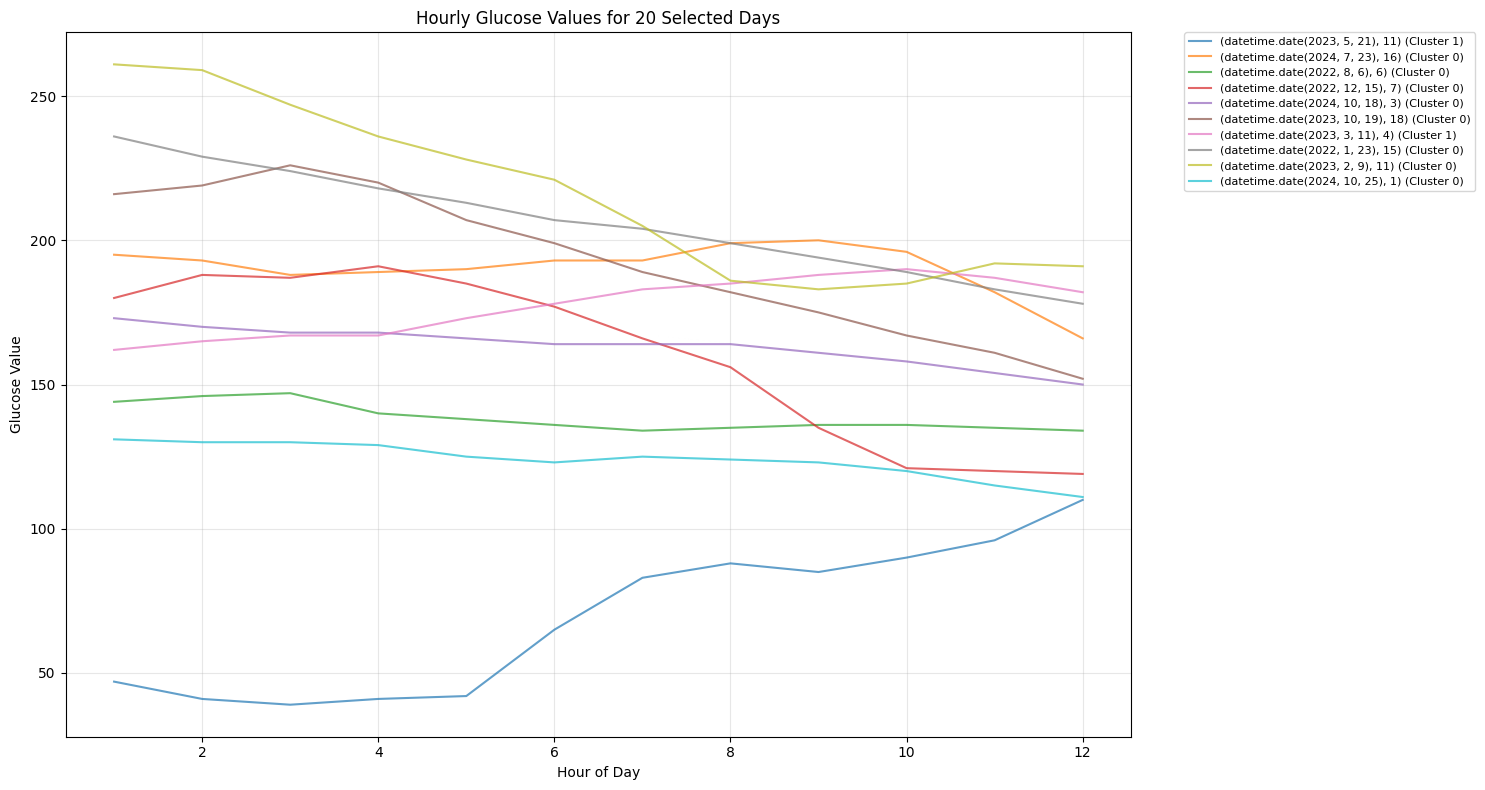

In [65]:
# Create the line plot
plt.figure(figsize=(15, 8))

# Plot each day's values
for idx in random_indices:
    values = df_hourly.iloc[idx][['value_1', 'value_2', 'value_3', 'value_4', 
                                 'value_5', 'value_6', 'value_7', 'value_8',
                                 'value_9', 'value_10', 'value_11', 'value_12']].values
    date_hour = df_hourly['date_hour'].iloc[idx]
    cluster = df_hourly['two_cluster'].iloc[idx]
    
    plt.plot(range(1, 13), values, 
             label=f'{date_hour} (Cluster {cluster})',
             alpha=0.7)

# Customize the plot
plt.xlabel('Hour of Day')
plt.ylabel('Glucose Value')
plt.title('Hourly Glucose Values for 20 Selected Days')
plt.grid(True, alpha=0.3)

# Add legend with smaller font size and place it outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), 
          loc='upper left', 
          borderaxespad=0.,
          fontsize=8)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.show()